# Jupyter Assignment 3, Gas Power Systems

Mech 330, Fall 2025

Group #:
Student ID numbers:
Names: 

In this project we will be using Cantera to do 2 things: (1) assessing the accuracy of constant specific heats, and (2) investigating a new thermodynamic cycle, called the Humphrey cycle. The performance of a new class of engines, called detonation engines, is approximated by the Humphrey cycle.

Because we will be working with ideal gases, instead of pure substances (e.g., water), we will do a short tutorial on using these in Cantera first.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cantera as ct

Working with ideal gases is very similar to working with pure substances (i.e., water). We will setup a gas object (instead of a water object), with the following code: `gas = ct.Solution('gri30.yaml')`

This gas object operates as an ideal gas, and can also have multiple components. For this assignment, we will just deal with 'engineering air', 1 mol $O_2$, 3.76 moles $N_2$. Otherwise, it behaves just as the water object we've used before: we can get or set various properties like enthalpy, entropy, temperature, and pressure.

A gas object with engineering air is setup below. Cantera uses internal relationships to calculate enthalpies and entropies more accurately than assuming constant heat capacities.

In [2]:
gas = ct.Solution('gri30.yaml')
gas.TPX = 300, 101325, 'O2:1, N2:3.76'  # 300K, 1atm, engineering air
gas()


  gri30:

       temperature   300 K
          pressure   1.0133e+05 Pa
           density   1.172 kg/m^3
  mean mol. weight   28.851 kg/kmol
   phase of matter   gas

                          1 kg             1 kmol     
                     ---------------   ---------------
          enthalpy            1907.6             55035  J
   internal energy            -84548       -2.4393e+06  J
           entropy            6891.7        1.9883e+05  J/K
    Gibbs function       -2.0656e+06       -5.9594e+07  J
 heat capacity c_p            1010.1             29141  J/K
 heat capacity c_v            721.87             20827  J/K

                      mass frac. Y      mole frac. X     chem. pot. / RT
                     ---------------   ---------------   ---------------
                O2             0.233           0.21008           -26.234
                N2             0.767           0.78992           -23.269
     [  +51 minor]                 0                 0  



### Problem 1: Air-standard Brayton cycle

<font color='blue'>1.1: **Without using cantera or ideal gas tables**, complete the following function to calculate the thermal efficiency of the ideal Brayton cycle (compressor and turbine isentropic efficiencies of 1, no pressure drop in heat exchangers) as a function of pressure ratio and $k$, using the cold-air standard properties and ideal gas relations. Use the function to plot the efficiency as a function of pressure ratio between 1 and 50, with $k = 1.4$ (accurate for engineering air at 300K). (1 point)</font>

Hint: you can use the formula for efficiency derived in Lecture 6.

Hint: check your work against Fig. 9.12 in the textbook.

![](./brayton.png)

Text(0, 0.5, 'Thermal efficiency')

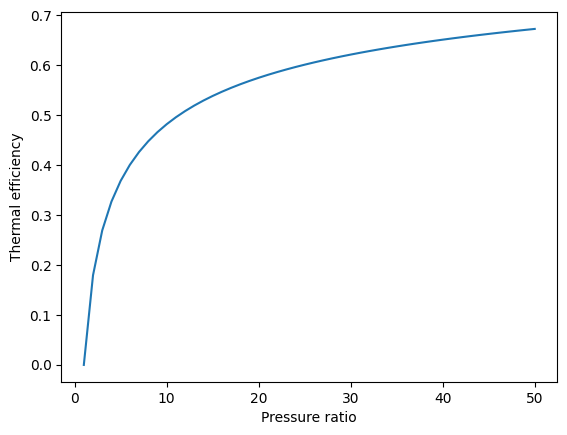

In [3]:
k = 1.4

def brayton_constant_k(pr, k):
    
    # YOUR CODE HERE
    eta = 1 - (1/(pr**((k-1)/k)))

    return eta

prs = np.linspace(1,50)
eta_ideal = np.zeros(len(prs))

for ii in range(len(prs)):
    eta_ideal[ii] = brayton_constant_k(prs[ii], k)

plt.plot(prs, eta_ideal)
plt.xlabel('Pressure ratio')
plt.ylabel('Thermal efficiency')

In [ ]:
# Autograde test cell

<font color='blue'>1.2: Now complete a new function, using cantera, to calculate the thermal efficiency of the ideal Brayton cycle, now only a function of pressure ratio. Calculate enthalpies of all states using cantera. Do not use constant specific heats (use a formula for eta using enthalpies). (3 points)</font>

Assume $T_1 = 300K$, $P_1 = 1atm$ and $T_{max} = T_3 = 1700K$ for all cases.

Text(0, 0.5, 'Thermal efficiency')

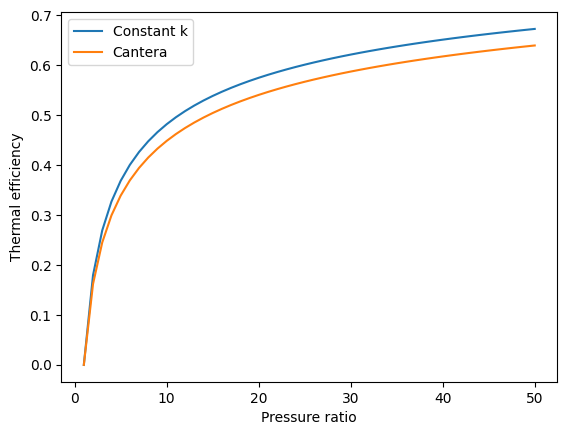

In [8]:
def brayton_cantera(pr):

    T3 = 1700  # K, maximum temperature
    T1 = 300   # K, initial temperature
    P1 = 101325 # Pa (1 atm), initial pressure
    
    gas = ct.Solution('gri30.yaml')
    gas.TPX = T1, P1, 'O2:1, N2:3.76'  # 300K, 1atm, engineering air, state 1


    h1 =  gas.h
    s1 = gas.s

    gas.SP = s1, P1*pr
    h2 = gas.h

    gas.TP = T3, P1*pr
    h3 = gas.h
    s3 = gas.s

    gas.SP = s3, P1
    h4 = gas.h
    eta = 1- (h4-h1)/(h3-h2)

    return eta

eta_cantera = np.zeros(len(prs))
for ii in range(len(prs)):
    eta_cantera[ii] = brayton_cantera(prs[ii])

plt.plot(prs, eta_ideal, label='Constant k')
plt.plot(prs, eta_cantera, label='Cantera')
plt.legend()
plt.xlabel('Pressure ratio')
plt.ylabel('Thermal efficiency')

In [ ]:
# Autograde test cell

You should observe that the two curves are not identical. It turns out that the value of $k$ is about 1.3 at high temperatures, and 1.4 at low temperatures (see code below). It does not depend on pressure.

In [4]:
gas.TP = 1700, 101325
print(f'k(T = 1700) = {gas.cp_mass / gas.cv_mass:.3f}')

gas.TP = 300, 101325
print(f'k(T = 300) = {gas.cp_mass / gas.cv_mass:.3f}')

k(T = 1700) = 1.303
k(T = 300) = 1.399


<font color='blue'>1.3: Use your `brayton_constant_k` function again, now for $k=1.35$ and $k=1.3$. Use the code below to plot all efficiency plots (all 3 values of $k$ and cantera solution) on the same plot. (1 point) </font>

Text(0, 0.5, 'Thermal efficiency')

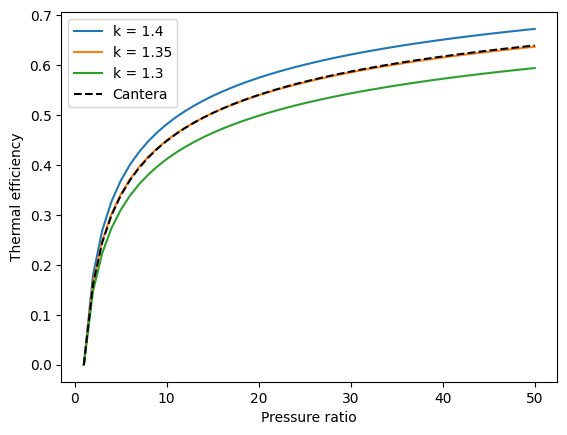

In [12]:
eta_k135 = np.zeros(len(prs))  # efficiency for k = 1.35
eta_k13 = np.zeros(len(prs))   # efficiency for k = 1.30
eta_ideal = np.zeros(len(prs))

for ii in range(len(prs)):
    eta_ideal[ii] = brayton_constant_k(prs[ii], 1.4)
    eta_k135[ii] = brayton_constant_k(prs[ii], 1.35)
    eta_k13[ii] = brayton_constant_k(prs[ii], 1.3)

plt.plot(prs, eta_ideal, label='k = 1.4')
plt.plot(prs, eta_k135, label='k = 1.35')
plt.plot(prs, eta_k13, label='k = 1.3')
plt.plot(prs, eta_cantera,'k--', label='Cantera')
plt.legend()
plt.xlabel('Pressure ratio')
plt.ylabel('Thermal efficiency')

You should observe that the in-between $k$ value behaves the best $(k=1.35)$. This is intuitive: the gas operates at both low and high temperature, so using an in-between value makes sense.

<font color='blue'>1.4: Use cantera to make a function to plot P-v **and** T-s diagrams for the ideal Brayton cycle for a pressure ratio of 5. Make sure to generate appropriate curved lines between states. Starter code is provided to help plotting. Use `axs[0].plot(x,y)` to plot on the left plot, and `axs[1].plot(x,y)` to plot on the right plot. Label the states, for example the first state can be labeled as `axs[0].text(v1,P1/1e5,'1',fontsize=14)`. (2 points) </font>

Hint: `gas.v` gives specific volume.

Hint: Your function will not return anything, simply call `axs[0].plot(x,y)` etc. within the function. We are doing it this way so we can use the function later.

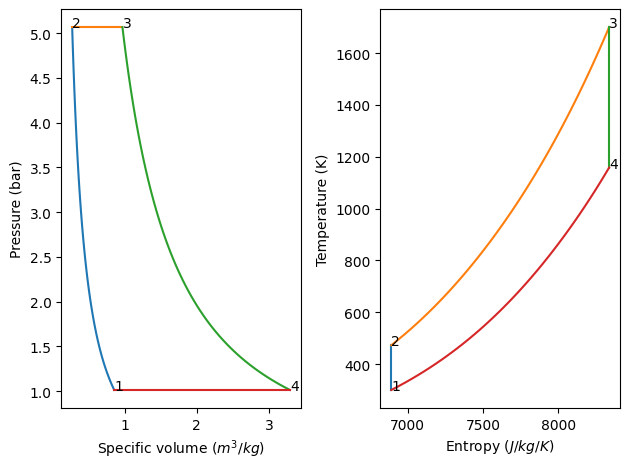

In [14]:
T1 = 300  # K
T3 = 1700  # K, maximum temperature
P1 = 101325 # Pa (1 atm), initial pressure
pr = 5

gas.TPX = T1, P1, 'O2:1, N2:3.76'  # 300K, 1atm, engineering air, state 1

def plot_brayton(axs):


    P2 = P1 * pr

    # state 1
    s1, v1, T1loc = gas.s, gas.v, gas.T

    # 1→2 isentropic
    P12 = np.geomspace(P1, P2, 60)
    v12, T12 = [], []
    for P in P12:
        gas.SP = s1, P
        v12.append(gas.v); T12.append(gas.T)
    v2, T2, s2 = v12[-1], T12[-1], gas.s

    # 2→3 @P2
    T23 = np.linspace(T2, T3, 60)
    v23, s23 = [], []
    for T in T23:
        gas.TP = T, P2
        v23.append(gas.v); s23.append(gas.s)
    v3, s3 = v23[-1], s23[-1]

    # 3→4 isentropic
    P34 = np.geomspace(P2, P1, 60)
    v34, T34 = [], []
    for P in P34:
        gas.SP = s3, P
        v34.append(gas.v); T34.append(gas.T)
    v4, T4, s4 = v34[-1], T34[-1], gas.s

    # 4→1 @P1
    T41 = np.linspace(T4, T1, 60)
    v41, s41 = [], []
    for T in T41:
        gas.TP = T, P1
        v41.append(gas.v); s41.append(gas.s)

    # P–v
    axs[0].plot(v12, P12/1e5)
    axs[0].plot(v23, np.full_like(v23, P2/1e5))
    axs[0].plot(v34, P34/1e5)
    axs[0].plot(v41, np.full_like(v41, P1/1e5))
    axs[0].text(v1, P1/1e5, '1')
    axs[0].text(v2, P2/1e5, '2')
    axs[0].text(v3, P2/1e5, '3')
    axs[0].text(v4, P1/1e5, '4')

    # T–s
    axs[1].plot([s1]*len(T12), T12)
    axs[1].plot(s23, T23)
    axs[1].plot([s3]*len(T34), T34)
    axs[1].plot(s41, T41)
    axs[1].text(s1, T1loc, '1')
    axs[1].text(s2, T2, '2')
    axs[1].text(s3, T3, '3')
    axs[1].text(s4, T4, '4')

fig1, axs = plt.subplots(1,2)
plot_brayton(axs)
axs[0].set_xlabel('Specific volume ($m^3/kg$)')
axs[0].set_ylabel('Pressure (bar)')
axs[1].set_xlabel('Entropy ($J/kg/K$)')
axs[1].set_ylabel('Temperature (K)')
fig1.tight_layout()

### Problem 2: Air-standard Humphrey cycle

The Humphrey cycle is similar to the Brayton cycle, except it replaces constant pressure heat addition  with constant volume heat addition. The Humphrey cycle approximates the thermodynamic behavior of using detonative combustion in place of standard (deflagrative) combustion. A new class of engines are emerging, called detonation engines, which operate on the Humphrey cycle. This problem will explore why researchers are excited about detonation engines, which is one of the topics of my research program.




<font color='blue'>2.1: Write a function, using cantera, to calculate the thermal efficiency of the Humphrey cycle, as a function of pressure ratio. Use the code provided to plot the efficiency as a function of pressure ratio between 1 and 50. The Brayton efficiency line from part 1.2 is also included. (4 points)</font>

Assume $T_1 = 300K$, $P_1 = 1atm$ and $T_{max} = T_3 = 1700K$ for all cases.

Hint: Use `gas.TD` to set temperature and density ($\rho = 1/v$)

![](./humphrey.png)

Text(0, 0.5, 'Thermal efficiency')

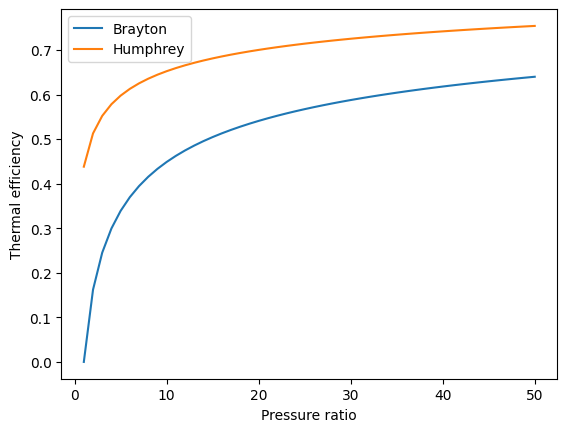

In [15]:
def humphrey_cantera(pr):

    T3 = 1700  # K, maximum temperature
    T1 = 300   # K, initial temperature
    P1 = 101325 # Pa (1 atm), initial pressure

    gas = ct.Solution('gri30.yaml')
    gas.TPX = T1, P1, 'O2:1, N2:3.76'  # 300K, 1atm, engineering air, state 1
    
    h1 =  gas.h
    s1 = gas.s

    gas.SP = s1, P1*pr
    h2 = gas.h
    v2 = gas.v


    gas.TD = T3, 1/v2
    h3 = gas.h
    s3 = gas.s

    gas.SP = s3, P1
    h4 = gas.h
    eta = 1- (h4-h1)/(h3-h2)
    

    return eta

eta_humphrey = np.zeros(len(prs))
for ii in range(len(prs)):
    eta_humphrey[ii] = humphrey_cantera(prs[ii])

plt.plot(prs, eta_cantera, label='Brayton')
plt.plot(prs, eta_humphrey, label='Humphrey')
plt.legend()
plt.xlabel('Pressure ratio')
plt.ylabel('Thermal efficiency')

In [ ]:
# Autograde test cell

You should find that the Humphrey cycle has substantially improved efficiency compared to the Brayton cycle, particularly at low pressure ratios. This means that engines could be both more efficienct, and also operate with fewer compressor stages, reducing system cost & complexity.

This simple analysis is motivating substantial research into detonation engine commercialization. Unfortunately designing these engines is not straight-forward. Challenges exist in designing heat transfer strategies and materials to withstand high temperatures, controlling detonation instabilities, and managing acoustics.

<font color='blue'>2.2: Use cantera to make a P-v diagram for the ideal Humphrey cycle for a pressure ratio of 5. Make sure to generate appropriate curved lines between states 1-2 and 3-4. Label the states. Use the code provided to plot the Humphrey and Brayton cycles on the same plot. Be sure to use different line colors for the 2 cycles (you can also use the `label='Humphrey'` command to one of the lines to show the 2 cycles within a legend). (2 points)</font>

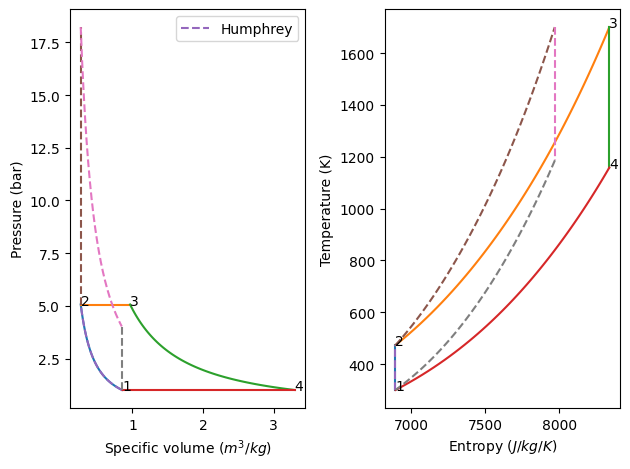

In [19]:
T1 = 300  # K
T3 = 1700  # K, maximum temperature
P1 = 101325 # Pa (1 atm), initial pressure
pr = 5
gas.TPX = T1, P1, 'O2:1, N2:3.76'  # 300K, 1atm, engineering air, state 1

def plot_humphrey(axs):
    P2 = P1 * pr

    # state 1
    gas.TPX = T1, P1, 'O2:1, N2:3.76'
    s1, v1 = gas.s, gas.v

    # 1→2 isentropic compression
    P12 = np.geomspace(P1, P2, 80)
    v12, T12 = [], []
    for P in P12:
        gas.SP = s1, P
        v12.append(gas.v); T12.append(gas.T)
    v2, T2 = v12[-1], T12[-1]

    # 2→3 constant-volume heat addition (ρ = 1/v2)
    T23 = np.linspace(T2, T3, 80)
    P23, s23 = [], []
    rho2 = 1.0 / v2
    for T in T23:
        gas.TD = T, rho2
        P23.append(gas.P); s23.append(gas.s)
    P3, s3 = P23[-1], s23[-1]

    # 3→4 isentropic expansion, stop when v ≈ v1
    Pscan = np.geomspace(P3, P1/50, 600)
    vscan, Tscan = [], []
    for P in Pscan:
        gas.SP = s3, P
        vscan.append(gas.v); Tscan.append(gas.T)
    i4 = int(np.argmin(np.abs(np.array(vscan) - v1)))
    P34 = Pscan[:i4+1]; v34 = vscan[:i4+1]; T34 = Tscan[:i4+1]
    P4, T4, v4, s4 = Pscan[i4], Tscan[i4], vscan[i4], gas.s  # v4≈v1

    # 4→1 constant-volume heat rejection (ρ = 1/v1)
    T41 = np.linspace(T4, T1, 80)
    P41, s41 = [], []
    rho1 = 1.0 / v1
    for T in T41:
        gas.TD = T, rho1
        P41.append(gas.P); s41.append(gas.s)

    # ---- P–v (bar) ----
    axs[0].plot(v12, P12/1e5, '--', label='Humphrey')
    axs[0].plot([v2]*len(P23), np.array(P23)/1e5, '--')
    axs[0].plot(v34, np.array(P34)/1e5, '--')
    axs[0].plot([v1]*len(P41), np.array(P41)/1e5, '--')

    # ---- T–s (J/kg/K) ----
    axs[1].plot([s1]*len(T12), T12, '--')
    axs[1].plot(s23, T23, '--')
    axs[1].plot([s3]*len(T34), T34, '--')
    axs[1].plot(s41, T41, '--')  # ends at (s1, T1) numerically




fig1, axs = plt.subplots(1,2)
plot_brayton(axs)
plot_humphrey(axs)

axs[0].legend()
axs[0].set_xlabel('Specific volume ($m^3/kg$)')
axs[0].set_ylabel('Pressure (bar)')
axs[1].set_xlabel('Entropy ($J/kg/K$)')
axs[1].set_ylabel('Temperature (K)')
fig1.tight_layout()